<a href="https://colab.research.google.com/github/bamacgabhann/PublicTransportTracking/blob/fyp2025/ptt-colab.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This code to analyse bus journeys uses the Python programming language.

The most important thing is to try and follow what is being done in each step: you don't need to understand the code.

But if you are interested in learning any of the coding, hopefully some of it will make sense, and I'll do my best to help.

You can click the play button beside each cell, in order, to run them - after making any required changes e.g. filenames.

First, run the cell below to connect your Google Drive

In [ ]:
if 'google.colab' in str(get_ipython()):
    from google.colab import drive
    drive.mount('/content/drive')

Now, we have to import some "libraries" (code already written by other people) to help.

In [1]:
if 'google.colab' in str(get_ipython()):
  !pip install osmnx movingpandas hvplot cartopy geoviews

import pandas as pd
import geopandas as gpd
import movingpandas as mpd
import matplotlib.pyplot as plt
import osmnx as ox

import hvplot.pandas

from datetime import datetime, timedelta
from shapely.geometry import Point, LineString, Polygon, box
from holoviews import opts

import warnings
warnings.filterwarnings("ignore")

plot_defaults = {"linewidth": 5, "capstyle": "round", "figsize": (10, 6), "legend": True}

## Journey data

In this cell, we tell the code where to find the files where we have saved the data for each journey from Strava.

A linked folder contains some data for Limerick, Belfast, and Carlow. To use your own data from Strava:

1. Upload your Strava data to the same Google Drive folder
2. Use the same format as the existing examples in the cell below to give a link to the journey data GPX file you want to analyse.

In [ ]:
Route_1_data_1 = "/content/drive/MyDrive/bus_fyp/Route_1_data_1.gpx"
Route_1_data_2 = "/content/drive/MyDrive/bus_fyp/Route_1_data_1.gpx"
Route_2_data_1 = "/content/drive/MyDrive/bus_fyp/Route_1_data_1.gpx"
Route_2_data_2 = "/content/drive/MyDrive/bus_fyp/Route_1_data_1.gpx"

## Other data

It would be useful to know where the bus stops are - luckily, I have maps of the stops for both CW1 and CW2 routes, in both directions.

In this cell, we get the code to read the bus stop data, so we can add it to our maps.

In [2]:
sligo_stops_S1_to_cairns_road = gpd.read_file('https://github.com/bamacgabhann/PublicTransportTracking/raw/refs/heads/fyp2025/places/sligo.gpkg', layer='stops_s1_to_cairns_road')
sligo_stops_S1_to_cartron = gpd.read_file('https://github.com/bamacgabhann/PublicTransportTracking/raw/refs/heads/fyp2025/places/sligo.gpkg', layer='stops_s1_to_cartron')
sligo_stops_S2_to_rosses_point = gpd.read_file('https://github.com/bamacgabhann/PublicTransportTracking/raw/refs/heads/fyp2025/places/sligo.gpkg', layer='stops_S2_to_rosses_point')
sligo_stops_S2_to_strandhill = gpd.read_file('https://github.com/bamacgabhann/PublicTransportTracking/raw/refs/heads/fyp2025/places/sligo.gpkg', layer='stops_S2_to_strandhill')

I've also got maps showing the areas within 400m walking distance - about a 5 minute walk - from each bus stop. This cell gets the code to read that data, so we can add that to the maps if we want.

**THIS PART NOT YET UPDATED FOR SLIGO**

In [ ]:
#CW1_north_stops_400m = gpd.read_file('https://github.com/bamacgabhann/PublicTransportTracking/raw/summerschool/GPKG/carlow/cw1_north_stops_400m.gpkg')
#CW1_south_stops_400m = gpd.read_file('https://github.com/bamacgabhann/PublicTransportTracking/raw/summerschool/GPKG/carlow/cw1_south_stops_400m.gpkg')
#CW2_east_stops_400m = gpd.read_file('https://github.com/bamacgabhann/PublicTransportTracking/raw/summerschool/GPKG/carlow/cw2_east_stops_400m.gpkg')
#CW2_west_stops_400m = gpd.read_file('https://github.com/bamacgabhann/PublicTransportTracking/raw/summerschool/GPKG/carlow/cw2_west_stops_400m.gpkg')

We might want to look at who is living in various parts of Carlow. We can use data from the Irish census for that. I've already put together the data for Carlow and the surrounding area - this cell tells the code to read that data, so we can plot it on a map if we want.

In [3]:
sligo_census = gpd.read_file('https://github.com/bamacgabhann/PublicTransportTracking/raw/refs/heads/fyp2025/places/sligo.gpkg', layer='sligo_sa_2022')

For some other things we might add, it would be useful to have a file defining the broad Sligo area, so we can look for other data within that area. This cell tells the code to read a file which has the shape of area around Sligo for which the file above has census data. It makes sense to use the same area for anything else we might want to add. There's also a slightly expanded version to make sure that roads around the edge of the area aren't excluded.

In [5]:
sligo_area = gpd.read_file('https://github.com/bamacgabhann/PublicTransportTracking/raw/refs/heads/fyp2025/places/sligo.gpkg', layer='sligo_area')
sligo_bounds = gpd.read_file('https://github.com/bamacgabhann/PublicTransportTracking/raw/refs/heads/fyp2025/places/sligo.gpkg', layer='sligo_area_10m_buffer')

## Analysing a journey
It's time to analyse a journey! The code below already specifies one of the journeys to analyse. To analyse a different journey, simple change the name of the journay to be analysed (use the name from the first cell under Journey Data above)

In [ ]:
gpx = Route_1_data_1

Now we tell the code to read this file, and show us the data for the chosen journey.

In [ ]:
gdf = gpd.read_file(gpx, layer="track_points").set_index("time")
gdf

You can see a lot of "NaN" above - there's a lot of columns with this, which means "Not a Number", meaning it has no data. We don't need all the empty columns, so the cell below tells the code to get rid of them, and show us the data we kept.

In [ ]:
gdf.drop(
    columns=[
        "magvar",
        "geoidheight",
        "name",
        "cmt",
        "desc",
        "src",
        "link1_href",
        "link1_text",
        "link1_type",
        "link2_href",
        "link2_text",
        "link2_type",
        "sym",
        "type",
        "fix",
        "sat",
        "hdop",
        "vdop",
        "pdop",
        "ageofdgpsdata",
        "dgpsid",
    ],
    inplace=True,
)
gdf = gdf.to_crs(2157)
track = mpd.Trajectory(gdf, 1)

track.df

This is much tidier. You can see here that each row has a date and time on the left, and has a POINT on the right. The POINT is the coordinates of where the bus was at the date and time of that row. Since we have coordinates, we can show that on a map:

In [ ]:
track.plot()

This is not a very useful map yet. One thing we can do to make it more useful is to add more data. For example, we could add some roads around Sligo. The first cell here gets the roads around Sligo from OpenStreetMap. The second cell plots a new map, showing the roads coloured according to category, with the bus journey in pink.

In [6]:
# create a box containing the route, expanded by 1000m, to use for extracting OpenStreetMap data
sligo_polygon = sligo_bounds.to_crs(4326).geometry[0]

#overlay_bounds = gpd.GeoDataFrame({"id":1,"geometry":[box(*gdf.total_bounds)]}).set_crs(2157)
#overlay_bounds['geometry'] = overlay_bounds['geometry'].buffer(1000)
#route_bounds = overlay_bounds.to_crs(4326).geometry[0]

# download the national, secondary, and local roads from OpenStreetMap in the area, cropping them to the map area
so_N_roads = ox.features_from_polygon(sligo_polygon, tags={'highway': ['trunk','trunk_link','primary','primary_link']})
so_N_roads = so_N_roads[so_N_roads.geom_type == 'LineString'].to_crs(2157).overlay(sligo_bounds, how='intersection')
so_R_roads = ox.features_from_polygon(sligo_polygon, tags={'highway': ['secondary','secondary_link']})
so_R_roads = so_R_roads[so_R_roads.geom_type == 'LineString'].to_crs(2157).overlay(sligo_bounds, how='intersection')
so_L_roads = ox.features_from_polygon(sligo_polygon, tags={'highway': ['tertiary','unclassified','residential','service', 'tertiary_link']})
so_L_roads = so_L_roads[so_L_roads.geom_type == 'LineString'].to_crs(2157).overlay(sligo_bounds, how='intersection')
so_P_roads = ox.features_from_polygon(sligo_polygon, tags={'highway': ['pedestrian']})
so_P_roads = so_P_roads[so_P_roads.geom_type == 'LineString'].to_crs(2157).overlay(sligo_bounds, how='intersection')

It might also be useful to see the buildings in the area - we can add those too.

In [7]:
# download the buildings
so_buildings = ox.features_from_polygon(sligo_polygon, tags = {"building": True})
so_buildings = so_buildings[so_buildings.geom_type == 'Polygon'].to_crs(2157).overlay(sligo_area, how='intersection')

It would also be useful to see where the bus stops are.

Change this cell to specifiy the correct bus stops for the journey you're analysing. There should be a # in front of each line except the one referring to the route of the journey to be analysed (the # symbol tells the code interpreter to ignore a line of code).

In [8]:
bus_stops = sligo_stops_S1_to_cairns_road
#bus_stops = sligo_stops_S1_to_cartron
#bus_stops = sligo_stops_S2_to_rosses_point
#bus_stops = sligo_stops_S2_to_strandhill

Now we need to use the time data for our bus journey.

Since we know what time the bus was at each point, if we calculate the distance we can also calculate the speed. We don't need to write complicated code for this - lucky for you, I already wrote the code to ask it to add columns for the distance from the previous point, and the speed in km/h.

If you want to have some fun with this - you can always try changing the units, for example if you want the speed in miles per minute. I'm not sure why you might want that, but you can do it if you want to!

In [ ]:
track.add_speed(name="speed (km/h)", units=("km", "h"))
track.add_distance(units="m")

track.df

Now we can plot the same map, but instead of showing the bus journey just as a pink line, we can colour it by what speed the bus was moving. Red for slow, green for fast, with a colour bar scale on the side.

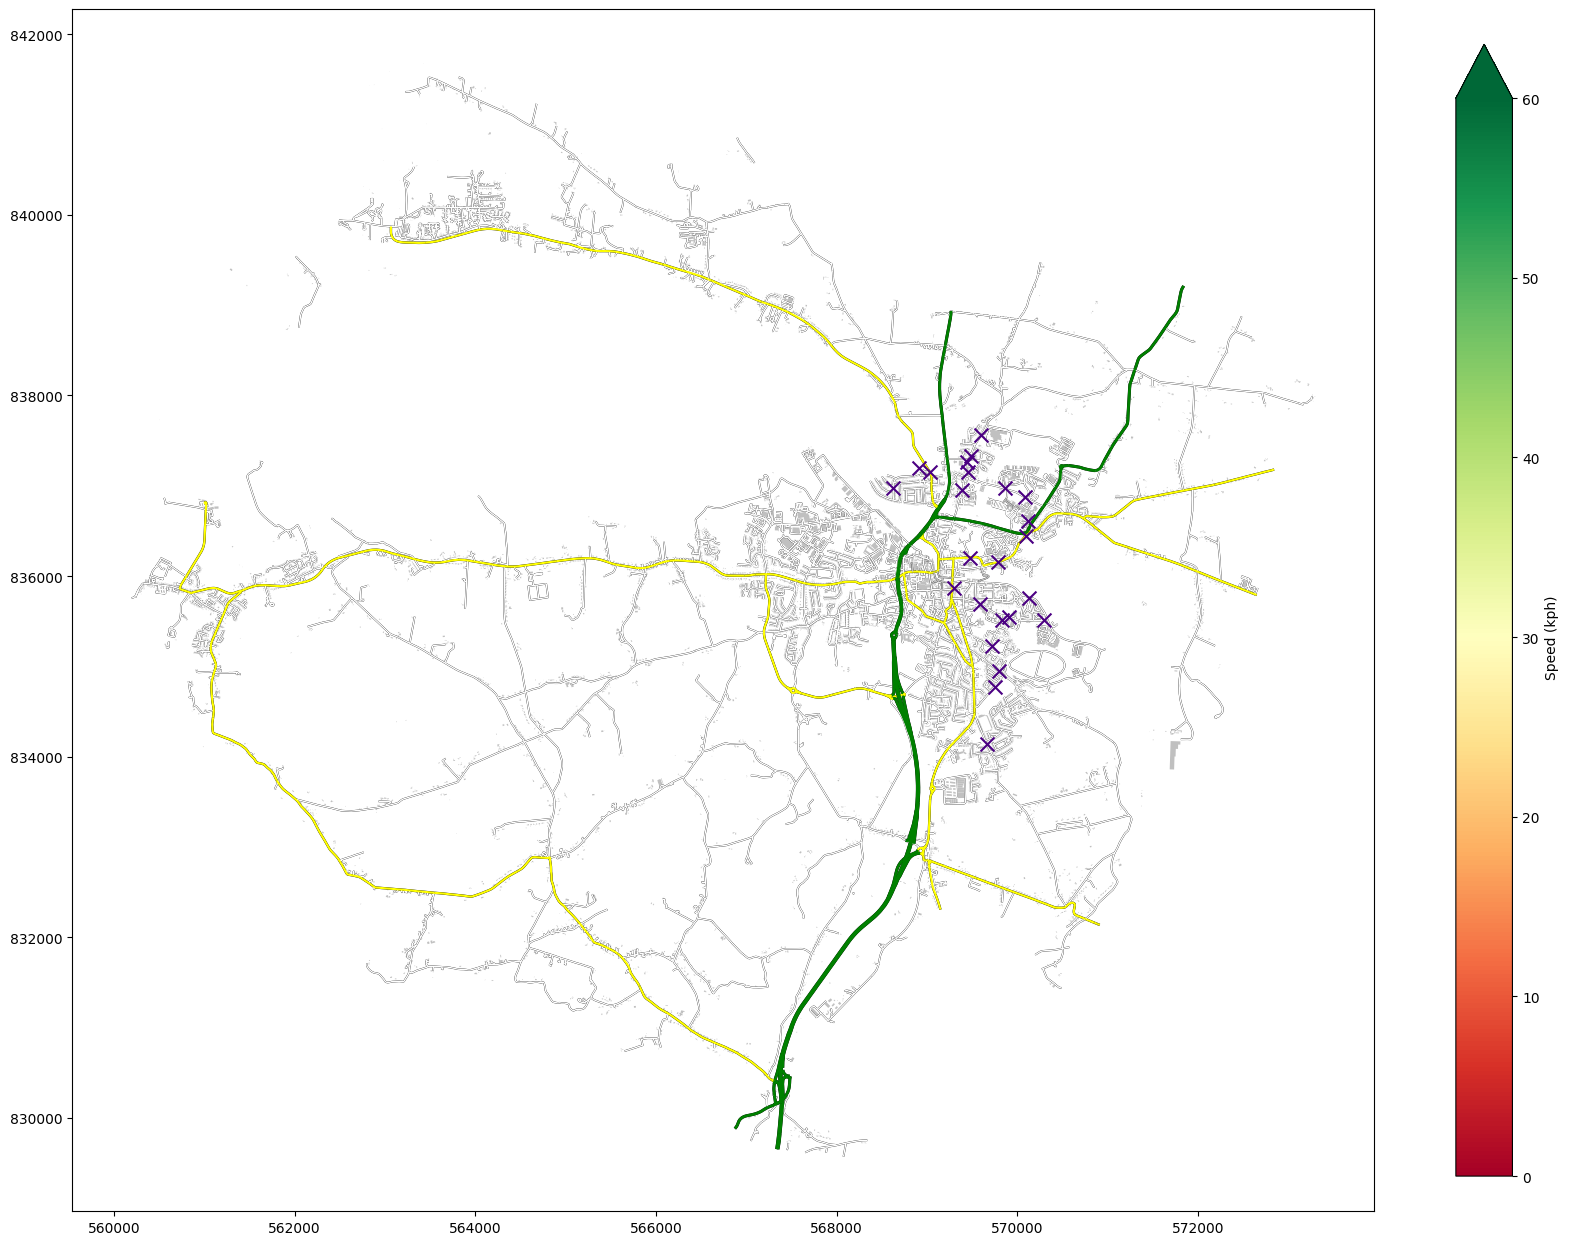

In [10]:
# plot
fig, ax = plt.subplots(figsize=(21, 21))

# plot all roads with a thicker black line which will show as edges,
# and a main line coloured by category
so_L_roads.plot(ax=ax, color='black', linewidth=1.2)
so_R_roads.plot(ax=ax, color='black', linewidth=1.7)
so_N_roads.plot(ax=ax, color='black', linewidth=2.2)
so_P_roads.plot(ax=ax, color='black', linewidth=1.1)
so_L_roads.plot(ax=ax, color='white', linewidth=1)
so_R_roads.plot(ax=ax, color='yellow', linewidth=1.5)
so_N_roads.plot(ax=ax, color='green', linewidth=2)
so_P_roads.plot(ax=ax, color='silver', linewidth=1)

# plot the buildings
so_buildings.plot(ax=ax, color='silver')

# plot the bus journey
#track.plot(ax=ax, column='speed (km/h)', cmap='RdYlGn', vmin=0, vmax=60, linewidth=4, zorder=2)

# plot the bus stops
bus_stops.plot(ax=ax, marker='x', color='indigo', markersize=100, zorder=3)

# colourbar
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=0, vmax=60))
cb = plt.colorbar(sm, ax=ax, extend='max', label="Speed (kph)", shrink=0.7)
cb.set_ticks([0, 10, 20, 30, 40, 50, 60])

plt.show()

Now *that* is a useful map.

On that map, we have some really useful data showing how fast the bus was moving. What about when it wasn't moving?

We can ask the code to identify places where the bus didn't move for some period of time. I've set this to 15 seconds, but you can change this if you like.

In [ ]:
stopped_time = 15

The next cell of code identifies stationary periods of this duration or longer within a 30m diameter circle.

In [ ]:
detector = mpd.TrajectoryStopDetector(track)
stationary_points = detector.get_stop_points(
    min_duration=timedelta(seconds=stopped_time), max_diameter=30
)

Let's add these points to our map:

In [ ]:
# plot the journey with the roads and buildings and bus stops
fig, ax = plt.subplots(figsize=(21, 21))

# plot all roads with a thicker black line which will show as edges,
# and a main line coloured by category
so_L_roads.plot(ax=ax, color='black', linewidth=1.2)
so_R_roads.plot(ax=ax, color='black', linewidth=1.7)
so_N_roads.plot(ax=ax, color='black', linewidth=2.2)
so_P_roads.plot(ax=ax, color='black', linewidth=1.1)
so_L_roads.plot(ax=ax, color='white', linewidth=1)
so_R_roads.plot(ax=ax, color='yellow', linewidth=1.5)
so_N_roads.plot(ax=ax, color='green', linewidth=2)
so_P_roads.plot(ax=ax, color='silver', linewidth=1)

# plot the buildings
so_buildings.plot(ax=ax, color='silver')

# plot the bus journey
track.plot(ax=ax, column='speed (km/h)', cmap='RdYlGn', vmin=0, vmax=60, linewidth=4, zorder=2)

# plot the bus stops
bus_stops.plot(ax=ax, marker='x', color='indigo', markersize=100, zorder=3)

# plot the stationary points
stationary_points.plot(ax=ax, marker='o', color='fuchsia', markersize=stationary_points['duration_s']*5)

# colourbar
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=0, vmax=60))
cb = plt.colorbar(sm, ax=ax, extend='max', label="Speed (kph)", shrink=0.7)
cb.set_ticks([0, 10, 20, 30, 40, 50, 60])

plt.show()

We can also ask the code to give us a list of these stationary points:

In [ ]:
stationary_points[1:]

And add up the total time spent stationary:

In [ ]:
stationary_points[1:]['duration_s'].sum()

That's in seconds, let's show it in a more familiar way (hours:minutes:seconds):

In [ ]:
minutes, seconds = divmod(stationary_points[1:]['duration_s'].sum(), 60)
print('0:{:02}:{:02}'.format(int(minutes), int(seconds)))

And compare it to the total journey time:

In [ ]:
print(track.get_duration())

What percentage of the journey time was spent stationary?

In [ ]:
timedelta(seconds=stationary_points[1:]['duration_s'].sum())/track.get_duration()*100

Does that seem like a lot to you?

We can also look at a version with the 400m walking distance zones around the bus stops shown. If you're mapping a different journey, change this to the correct set for your journey.

**THIS PART NOT YET UPDATED FOR SLIGO**

In [ ]:
zones_400m = NANANANANANANAN

In [ ]:
# plot the journey with the roads and buildings and bus stops
fig, ax = plt.subplots(figsize=(21, 21))

# plot all roads with a thicker black line which will show as edges,
# and a main line coloured by category
so_L_roads.plot(ax=ax, color='black', linewidth=1.2)
so_R_roads.plot(ax=ax, color='black', linewidth=1.7)
so_N_roads.plot(ax=ax, color='black', linewidth=2.2)
so_P_roads.plot(ax=ax, color='black', linewidth=1.1)
so_L_roads.plot(ax=ax, color='white', linewidth=1)
so_R_roads.plot(ax=ax, color='yellow', linewidth=1.5)
so_N_roads.plot(ax=ax, color='green', linewidth=2)
so_P_roads.plot(ax=ax, color='silver', linewidth=1)

# plot the buildings
so_buildings.plot(ax=ax, color='silver')

# plot the bus journey
track.plot(ax=ax, column='speed (km/h)', cmap='RdYlGn', vmin=0, vmax=60, linewidth=4, zorder=2)

# plot the bus stops
bus_stops.plot(ax=ax, marker='x', color='indigo', markersize=100, zorder=3)

# plot the stationary points
stationary_points.plot(ax=ax, marker='o', color='fuchsia', markersize=stationary_points['duration_s']*5)

# plot the 400m walking distance routes
#zones_400m.plot(ax=ax, color='fuchsia', linewidth=3, zorder=1)

# colourbar
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=0, vmax=60))
cb = plt.colorbar(sm, ax=ax, extend='max', label="Speed (kph)", shrink=0.7)
cb.set_ticks([0, 10, 20, 30, 40, 50, 60])

plt.show()

And we can also plot census data to show how many people are living in various areas - darker blue means more total people.

In [ ]:
# plot the journey with the roads and buildings and bus stops
fig, ax = plt.subplots(figsize=(21, 21))

#there is more we can do with the census data, but this is an example for now
sligo_census.plot(ax=ax, column='T1_1AGETT', cmap='Blues', vmin=0, vmax=650, zorder=1) 

# plot all roads with a thicker black line which will show as edges,
# and a main line coloured by category
so_L_roads.plot(ax=ax, color='black', linewidth=1.2)
so_R_roads.plot(ax=ax, color='black', linewidth=1.7)
so_N_roads.plot(ax=ax, color='black', linewidth=2.2)
so_P_roads.plot(ax=ax, color='black', linewidth=1.1)
so_L_roads.plot(ax=ax, color='white', linewidth=1)
so_R_roads.plot(ax=ax, color='yellow', linewidth=1.5)
so_N_roads.plot(ax=ax, color='green', linewidth=2)
so_P_roads.plot(ax=ax, color='silver', linewidth=1)

# plot the buildings
so_buildings.plot(ax=ax, color='silver')

# plot the bus journey
track.plot(ax=ax, column='speed (km/h)', cmap='RdYlGn', vmin=0, vmax=60, linewidth=4, zorder=2)

# plot the bus stops
bus_stops.plot(ax=ax, marker='x', color='indigo', markersize=100, zorder=3)

# plot the stationary points
stationary_points.plot(ax=ax, marker='o', color='fuchsia', markersize=stationary_points['duration_s']*5)

# plot the 400m walking distance routes
#zones_400m.plot(ax=ax, color='fuchsia', linewidth=3, zorder=1)

# colourbar
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=0, vmax=60))
cb = plt.colorbar(sm, ax=ax, extend='max', label="Speed (kph)", shrink=0.7)
cb.set_ticks([0, 10, 20, 30, 40, 50, 60])

plt.show()

There's a lot more census data than just the total number of people - if you're interested in looking at what else might be in there, I'd be happy to show you.

Now, try another journey. How does it compare?